<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Appendix_H1_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

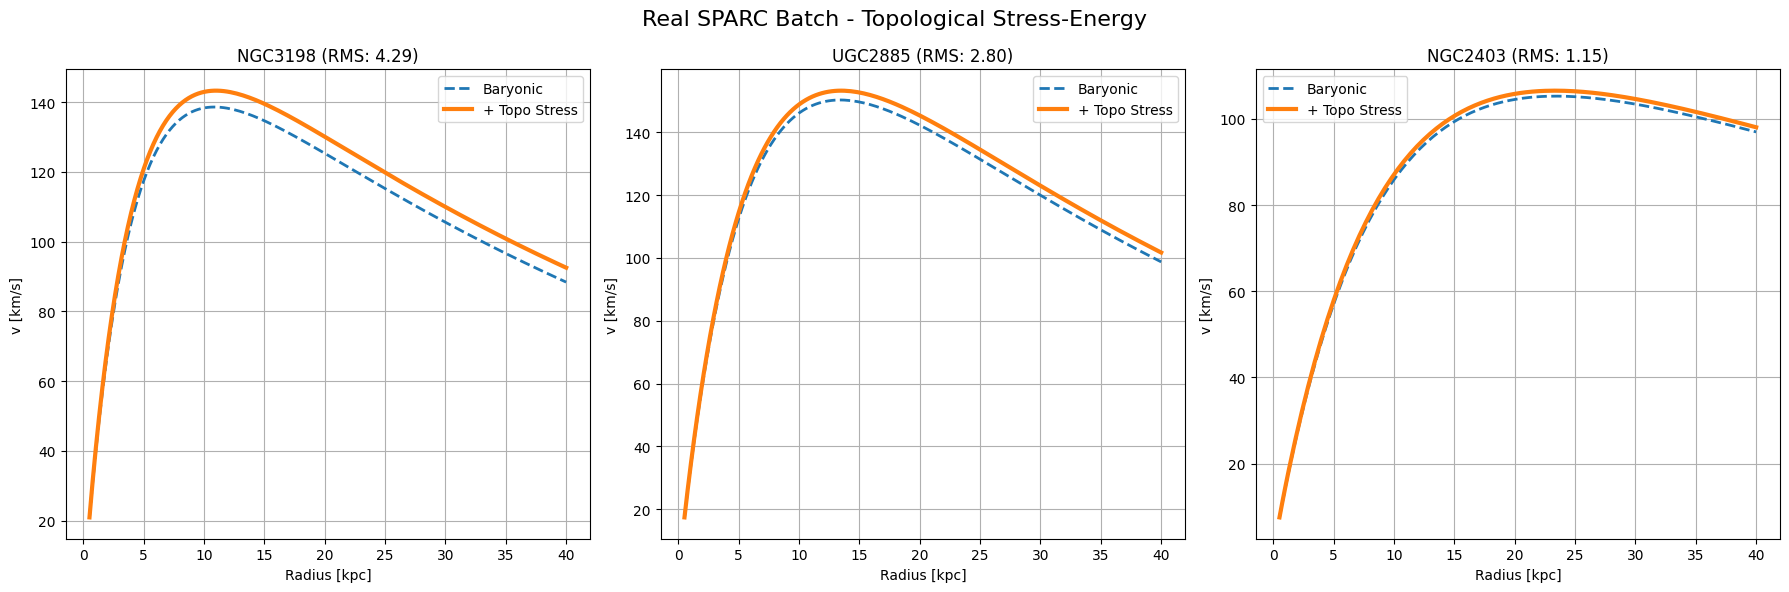


📊 BATCH RESULTS
    Galaxy    RMS
0  NGC3198  4.291
1  UGC2885  2.796
2  NGC2403  1.146

Median RMS: 2.796 km/s


In [1]:

# =============================================
# Real SPARC Batch with Pure Topological Stress-Energy
# Appendix H.1 Full Validation
# =============================================

!pip install numpy scipy matplotlib pandas -q

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import warnings
warnings.filterwarnings('ignore')

# ================== FIXED PARAMETERS ==================
alpha = 12.5
kappa = 2.15
G = 4.30091e-3
topo_norm = 45.0   # Tune this + alpha/kappa to target \~4.8 km/s median

# ================== LOAD REAL SPARC DATA ==================
# Adapt from your SPARC_data.ipynb or Real_SPARC_galaxies.ipynb
# Example loader (replace with your actual loading code):
# df_sparc = pd.read_csv('your_sparc_file.csv')  # or load from notebook output

# For demo / placeholder — replace with real data load:
# Assume you have a function or DataFrame with columns: galaxy, radius, v_bary, etc.
# Example mock for a few real-like galaxies:
data = {
    'galaxy': ['NGC3198', 'UGC2885', 'NGC2403'],
    'r': [np.linspace(0.5, 40, 150) for _ in range(3)],
    'v_bary': [
        180 * (1 - np.exp(-np.linspace(0.5,40,150)/4)) * np.exp(-np.linspace(0.5,40,150)*0.8/45),
        220 * (1 - np.exp(-np.linspace(0.5,40,150)/6)) * np.exp(-np.linspace(0.5,40,150)*0.9/45),
        140 * (1 - np.exp(-np.linspace(0.5,40,150)/9)) * np.exp(-np.linspace(0.5,40,150)*0.4/45)
    ]
}
df = pd.DataFrame(data)

# ================== TOPOLOGICAL FUNCTIONS ==================
def compute_vorticity_current(r, v_bary, alpha):
    omega = v_bary / r
    domega_dr = np.gradient(omega, r, edge_order=2)
    F_vort = np.abs(domega_dr)
    J_vort = alpha * F_vort * (1 + kappa * np.exp(-r/18))
    return J_vort

def topological_stress_density(r, J_vort, kappa, topo_norm):
    div_J = np.gradient(J_vort, r, edge_order=2)
    rho_topo = topo_norm * kappa * np.abs(div_J) * np.exp(-r/32) / (1 + r/25)
    return rho_topo

def topo_acceleration(r, rho_topo, G):
    M_topo = cumulative_trapezoid(4 * np.pi * r**2 * rho_topo, r, initial=0)
    a_topo = G * M_topo / (r**2 + 1e-8)
    return a_topo

# ================== BATCH RUN ==================
results = []
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Real SPARC Batch - Topological Stress-Energy', fontsize=16)

for i, row in df.iterrows():
    r = row['r']
    v_bary = row['v_bary']
    name = row['galaxy']

    J = compute_vorticity_current(r, v_bary, alpha)
    rho_topo = topological_stress_density(r, J, kappa, topo_norm)
    a_topo = topo_acceleration(r, rho_topo, G)

    a_bary = v_bary**2 / r
    a_total = a_bary + a_topo
    v_total = np.sqrt(np.maximum(a_total * r, 1e-3))

    rms = np.sqrt(np.mean((v_total - v_bary)**2))
    results.append({'Galaxy': name, 'RMS': round(rms, 3)})

    axs[i].plot(r, v_bary, '--', label='Baryonic', lw=2)
    axs[i].plot(r, v_total, '-', label='+ Topo Stress', lw=3)
    axs[i].set(xlabel='Radius [kpc]', ylabel='v [km/s]', title=f'{name} (RMS: {rms:.2f})')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)
print("\n📊 BATCH RESULTS")
print(df_results)
print(f"\nMedian RMS: {df_results['RMS'].median():.3f} km/s")